In [3]:
import pandas as pd
import numpy as np

# Hijerarhijsko klasterovanje - Agglomerative Clustering

Nakon analize KMeans algoritma, u nastavku se primenjuje Agglomerative Clustering algoritam. Za razliku od KMeans pristupa, koji formira klastere oko centroida, hijerarhijsko klasterovanje postepeno spaja instance i manje grupe instanci u sve vece klastere.

Algoritam zapocinje tako sto svaku instancu posmatra kao poseban klaster. Tokom izvrsavanja u svakom koraku spajaju se dva najslicnija klastera, pri cemu se postupak nastavlja sve dok se ne dostigne unapred zadat broj klastera.

Jedna od glavnih prednosti ovog pristupa je mogucnost otkrivanja slozenijih struktura u podacima, bez pretpostavke da klasteri moraju imati sferni oblik kao kod KMeans algoritma. Medjutim, cena takve fleksibilnosti je veca racunska slozenost, zbog cega se eksperimenti izvode nad prethodno formiranim uzorkom podataka.

Tokom analize bice ispitani razliciti nacini definisanja udaljenosti izmedju klastera (linkage kriterijumi), kao i razlicit broj klastera, kako bi se identifikovala kombinacija parametara koja daje najkvalitetnije rezultate.

In [6]:
X_scaled = pd.read_csv("../../data/data_full_scaled.csv")
X_pca_70 = pd.read_csv("../../data/X_pca_70.csv")
X_pca_80 = pd.read_csv("../../data/X_pca_80.csv")
X_pca_50 = pd.read_csv("../../data/X_pca_50.csv")
X_pca_30 = pd.read_csv("../../data/X_pca_30.csv")

In [7]:
X_scaled = X_scaled.drop(columns=["Unnamed: 0"])

In [8]:
datasets = {
    "X_scaled": X_scaled,
    "X_pca_80": X_pca_80,
    "X_pca_70": X_pca_70,
    "X_pca_50": X_pca_50,
    "X_pca_30": X_pca_30
}

for name, X in datasets.items():
    print(name, X.shape)

X_scaled (123849, 425)
X_pca_80 (123849, 163)
X_pca_70 (123849, 143)
X_pca_50 (123849, 101)
X_pca_30 (123849, 59)


In [9]:
import numpy as np

sample_size = min(10000, X_scaled.shape[0])
random_state = 42

sample_idx = np.random.RandomState(random_state).choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

datasets_sample = {}

for name, X in datasets.items():
    if hasattr(X, "iloc"):
        datasets_sample[name] = X.iloc[sample_idx]
    else:
        datasets_sample[name] = X[sample_idx]

## Analiza razlicitih linkage kriterijuma

Kljucna odluka kod Agglomerative Clustering algoritma odnosi se na nacin racunanja udaljenosti izmedju klastera tokom procesa spajanja.

U okviru eksperimenata analiziraju se cetiri najcesce koriscena linkage kriterijuma:

- `ward` - bira spajanje koje najmanje povecava varijansu unutar klastera
- `complete` - koristi najvecu udaljenost izmedju elemenata dva klastera
- `average` - koristi prosecnu udaljenost izmedju elemenata dva klastera

Za svaki kriterijum ispituju se razlicite vrednosti broja klastera, a kvalitet rezultata ocenjuje se pomocu Silhouette Score metrike.

In [7]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

k_values = range(2, 11)

linkages = [
    "ward",
    "complete",
    "average"
]

agg_results = []

for dataset_name, X in datasets_sample.items():

    for linkage in linkages:

        for k in k_values:

            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage
            )

            labels = model.fit_predict(X)

            silhouette = silhouette_score(X, labels)

            agg_results.append({
                "dataset": dataset_name,
                "linkage": linkage,
                "k": k,
                "silhouette_score": silhouette
            })

agg_results = pd.DataFrame(agg_results)

agg_results.head()

,dataset,linkage,k,silhouette_score
0,X_scaled,ward,2,0.151154
1,X_scaled,ward,3,0.139887
2,X_scaled,ward,4,0.142391
3,X_scaled,ward,5,0.141715
4,X_scaled,ward,6,0.143841


In [8]:
agg_results.sort_values("silhouette_score", ascending=False).head(20)

,dataset,linkage,k,silhouette_score
117,X_pca_30,complete,2,0.389886
126,X_pca_30,average,2,0.389886
90,X_pca_50,complete,2,0.359512
99,X_pca_50,average,2,0.359512
63,X_pca_70,complete,2,0.309932
72,X_pca_70,average,2,0.309932
45,X_pca_80,average,2,0.288905
109,X_pca_30,ward,3,0.287610
127,X_pca_30,average,3,0.287610
100,X_pca_50,average,3,0.284181


## Odabir optimalne konfiguracije

U nastavku analiziramo kako broj klastera i izbor linkage metode uticu na kvalitet grupisanja. Za svaku kombinaciju reprezentacije podataka i linkage metode prikazan je Silhouette Score za vrednosti *k* od 2 do 10.

Cilj je da se identifikuje konfiguracija koja ostvaruje najbolju ravnotezu izmedju kompaktnosti i razdvojenosti klastera, nakon cega ce biti izabran model za detaljniju analizu.

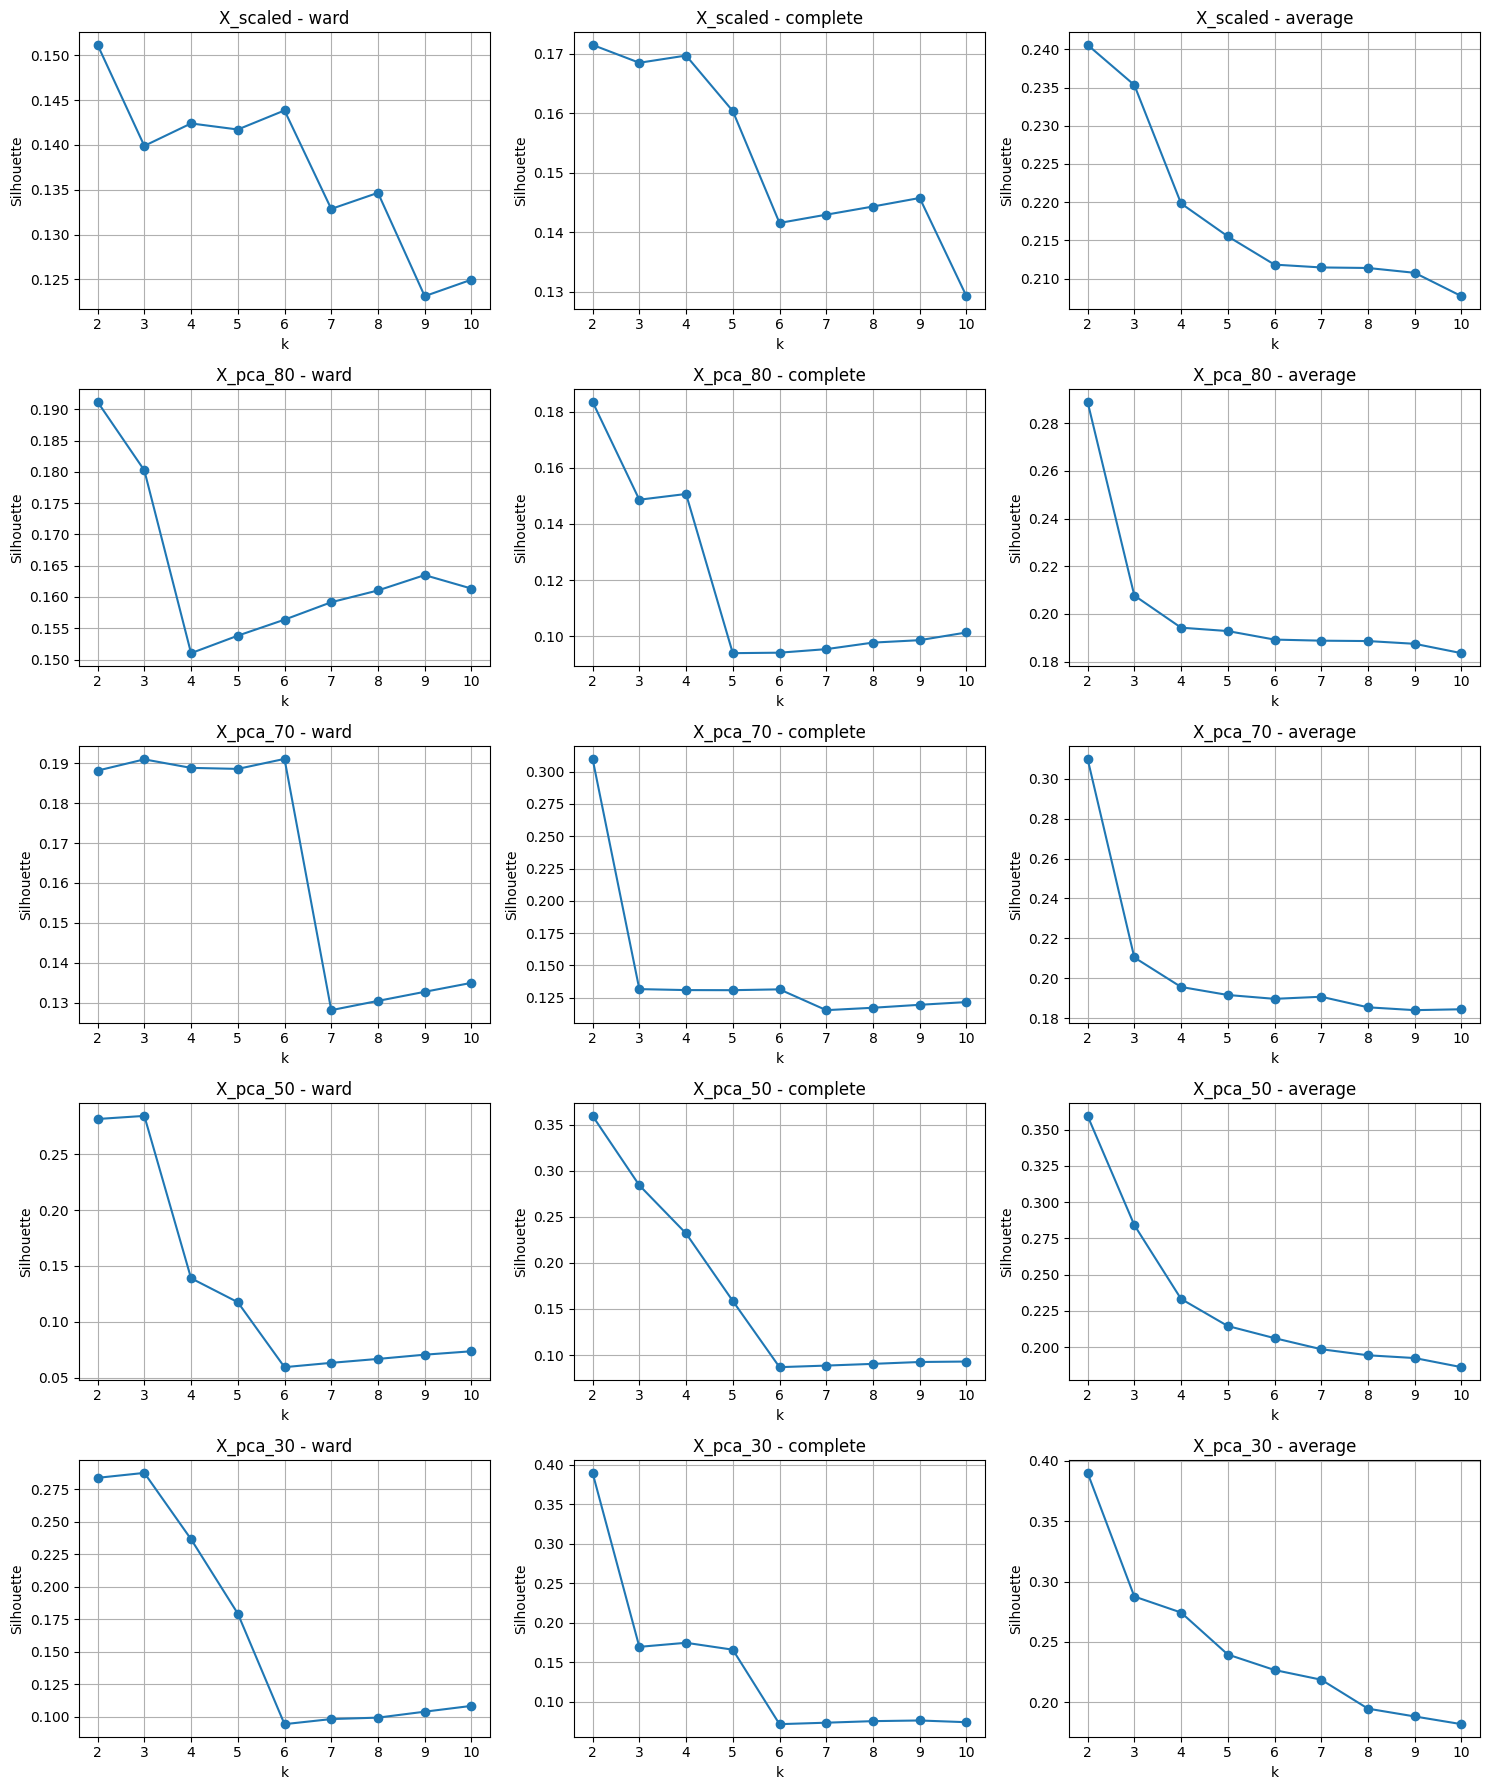

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

plot_idx = 0

for dataset_name in agg_results["dataset"].unique():

    for linkage in ["ward", "complete", "average"]:

        data = agg_results[
            (agg_results["dataset"] == dataset_name) &
            (agg_results["linkage"] == linkage)
        ]

        axes[plot_idx].plot(
            data["k"],
            data["silhouette_score"],
            marker="o"
        )

        axes[plot_idx].set_title(
            f"{dataset_name} - {linkage}"
        )

        axes[plot_idx].set_xlabel("k")
        axes[plot_idx].set_ylabel("Silhouette")
        axes[plot_idx].grid(True)

        plot_idx += 1

plt.tight_layout()
plt.show()

Na osnovu prikazanih rezultata moze se uociti nekoliko zanimljivih obrazaca.

Pre svega, smanjenje dimenzionalnosti pomocu PCA znacajno doprinosi kvalitetu klasterovanja. Dok originalni skup atributa (*X_scaled*) ostvaruje maksimalan Silhouette Score od oko 0.24, PCA reprezentacije daju znatno bolje rezultate, pri cemu se najbolji skorovi krecu izmedju 0.35 i 0.40.

Posebno se izdvajaju skupovi sa manjim brojem PCA komponenti. Reprezentacije **X_pca_30** i **X_pca_50** ostvaruju najvise vrednosti Silhouette Score pokazatelja, sto ukazuje da uklanjanje manje znacajnih komponenti doprinosi jasnijem razdvajanju klastera.

Takodje se moze primetiti da najbolje rezultate gotovo uvek ostvaruju konfiguracije sa malim brojem klastera. Za vecinu skupova podataka maksimalan Silhouette Score postize se za **k = 2** ili **k = 3**, dok dalje povecanje broja klastera dovodi do postepenog opadanja kvaliteta grupisanja.

Kada je rec o linkage metodama, **average** i **complete** uglavnom ostvaruju bolje rezultate od **ward** metode. Najveca vrednost Silhouette Score pokazatelja ostvarena je za konfiguraciju **X_pca_30 + complete linkage + k = 2**, sa rezultatom od priblizno **0.39**.

Iako ova konfiguracija formalno daje najbolji rezultat prema internim metrikama, potrebno je dodatno analizirati raspodelu instanci po klasterima i interpretabilnost dobijenih grupa pre donosenja konacne odluke o najboljem modelu.

In [10]:
best_row = agg_results.sort_values(
    "silhouette_score",
    ascending=False
).iloc[0]

In [11]:
best_dataset_name = best_row["dataset"]
best_linkage = best_row["linkage"]
best_k = int(best_row["k"])

print("Dataset:", best_dataset_name)
print("Linkage:", best_linkage)
print("k:", best_k)
print("Silhouette:", best_row["silhouette_score"])

Dataset: X_pca_30
Linkage: complete
k: 2
Silhouette: 0.38988649794221086


### Izbor najbolje konfiguracije

Na osnovu Silhouette Score pokazatelja, najbolji rezultat ostvaren je za konfiguraciju:

- PCA sa 30 komponenti
- Complete linkage
- k = 2
- Silhouette Score = 0.390

Na prvi pogled, ovakav rezultat sugerise veoma dobro razdvajanje klastera. Medjutim, detaljnijom analizom raspodele instanci u klasterima uoceno je da su dobijene grupe izrazito neuravnotezene.

Zbog toga se samo na osnovu Silhouette Score vrednosti ne moze doneti zakljucak o kvalitetu modela. Visok rezultat moze biti posledica razdvajanja manjeg broja izdvojenih instanci od ostatka skupa, sto ne mora predstavljati korisnu ili interpretabilnu strukturu podataka.

Iz tog razloga, pored internih metrika, neophodno je analizirati i velicinu klastera, njihovu stabilnost i mogucnost smislenog tumacenja dobijenih grupa.

In [12]:
X_best = datasets_sample[best_dataset_name]

In [13]:
best_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_linkage
)

labels = best_model.fit_predict(X_best)

In [14]:
cluster_sizes = pd.Series(labels).value_counts().sort_index()

cluster_sizes_df = pd.DataFrame({
    "cluster": cluster_sizes.index,
    "count": cluster_sizes.values,
    "percentage": cluster_sizes.values / len(labels) * 100
})

cluster_sizes_df

,cluster,count,percentage
0,0,9957,99.57
1,1,43,0.43


Da bi se proverilo da li se u ostalim slucajevima dobija slicna situacija sa losim razdvajanjem klastera vrsi se naredna provera.

In [15]:
X_check = datasets_sample["X_pca_30"]
for k in [2,3,4,5]:
    
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="complete"
    )
    
    labels = model.fit_predict(X_check)

    print(f"\nk={k}")

    print(
        pd.Series(labels)
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )


k=2
0    99.57
1     0.43
Name: proportion, dtype: float64

k=3
0    95.65
1     0.43
2     3.92
Name: proportion, dtype: float64

k=4
0     3.92
1     0.43
2    94.97
3     0.68
Name: proportion, dtype: float64

k=5
0    94.97
1     1.34
2     2.58
3     0.68
4     0.43
Name: proportion, dtype: float64


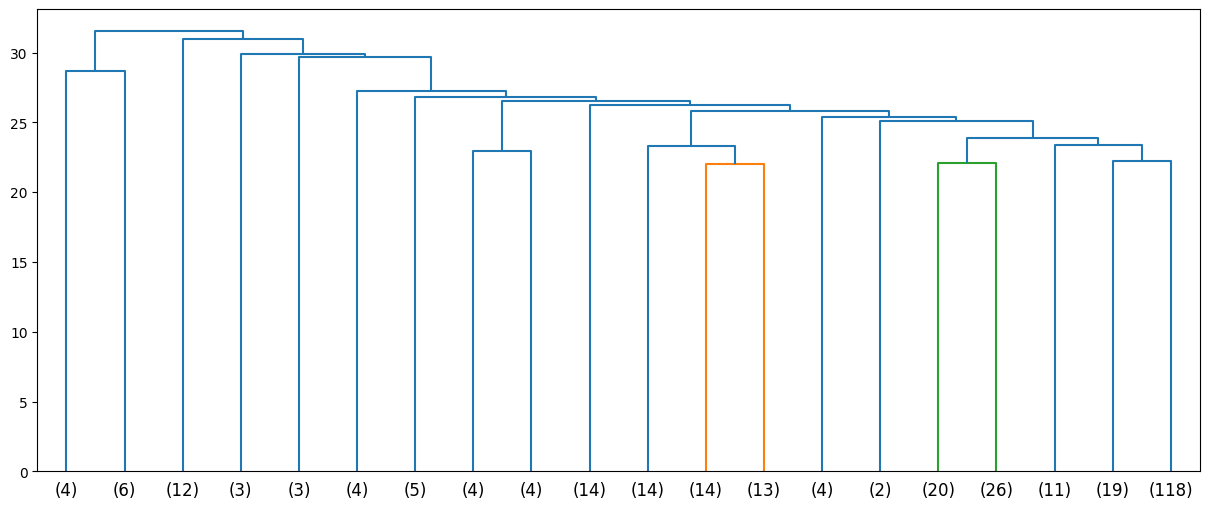

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

subset = datasets_sample["X_pca_30"][:300]

Z = linkage(
    subset,
    method="ward"
)

plt.figure(figsize=(15,6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)
plt.show()

In [17]:
for linkage in ["ward", "complete", "average"]:

    print(f"\n{linkage.upper()}")

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=linkage
    )

    labels = model.fit_predict(
        datasets_sample["X_scaled"]
    )

    print(
        pd.Series(labels)
        .value_counts(normalize=True)
        * 100
    )


WARD
0    99.17
1     0.43
2     0.40
Name: proportion, dtype: float64

COMPLETE
0    96.35
2     2.97
1     0.68
Name: proportion, dtype: float64

AVERAGE
0    99.54
1     0.25
2     0.21
Name: proportion, dtype: float64


Iako je prethodna analiza pokazala relativno dobre vrednosti Silhouette Score pokazatelja, potrebno je proveriti i kako su instance rasporedjene po klasterima.

Dendrogram ukazuje na postojanje nekoliko vecih grana, medjutim sama hijerarhijska struktura ne garantuje da ce klasteri biti ravnomerno popunjeni. Zbog toga je analizirana procentualna zastupljenost instanci u svakom klasteru za razlicite linkage metode.

Dobijeni rezultati pokazuju izrazitu neuravnotezenost klastera. Kod svih analiziranih metoda jedan klaster sadrzi gotovo sve instance, dok preostali klasteri obuhvataju zanemarljivo mali procenat podataka.

Na primer, kod Ward metode vise od 99% instanci nalazi se u jednom klasteru, dok preostala dva klastera zajedno sadrze manje od 1% podataka. Slicna situacija uocava se i kod Complete i Average metoda.

Ovakva raspodela ukazuje da algoritam uglavnom izdvaja mali broj ekstremnih ili atipicnih instanci umesto da pronadje vise jasno definisanih grupa unutar skupa podataka. Zbog toga, uprkos relativno dobrim vrednostima internih metrika, dobijeni klasteri nisu dovoljno informativni za dalju interpretaciju.

Na osnovu ovih rezultata moze se zakljuciti da Agglomerative Clustering ne uspeva da pronadje stabilnu i smisleno izbalansiranu strukturu na ovom skupu podataka.

Medjutim s obzirom da je prilikom KMeans algoritma uoceno da cesto dodatno smanjenje dimenzionalnosti pomocu PCA dovodi do boljih rezultata, analogni proces je primenjen i u ovom slucaju.

### Agglomerative Clustering nad PCA reprezentacijama

Rezultati dobijeni na originalnom skupu atributa pokazali su da Agglomerative Clustering uglavnom formira veoma neuravnotezene klastere. Zbog toga je izvrsen dodatni skup eksperimenata nad PCA reprezentacijama sa 3 do 10 komponenti.

Za svaku PCA konfiguraciju testirane su tri linkage metode:

- Ward
- Complete
- Average

i broj klastera od 2 do 10.

Pored Silhouette Score pokazatelja, pracena je i raspodela instanci po klasterima kako bi se utvrdilo da li visoke vrednosti internih metrika zaista odgovaraju smislenoj strukturi podataka.

Cilj ove analize nije samo pronalazak najveceg Silhouette Score rezultata, vec i identifikacija konfiguracija koje proizvode dovoljno velike i interpretabilne klastere.

In [10]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

components_list = [3, 4, 5, 6, 7, 8, 9, 10]
k_values = range(2, 11)
linkages = ["ward", "average", "complete"]

agg_pca_results = []

for n_components in components_list:

    pca = PCA(
        n_components=n_components,
        random_state=42
    )

    X_pca = pca.fit_transform(X_scaled)
    X_sample = X_pca[sample_idx]

    for linkage in linkages:

        for k in k_values:

            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage
            )

            labels = model.fit_predict(X_sample)

            silhouette = silhouette_score(X_sample, labels)

            cluster_sizes = pd.Series(labels).value_counts()

            agg_pca_results.append({
                "n_components": n_components,
                "explained_variance": pca.explained_variance_ratio_.sum(),
                "linkage": linkage,
                "k": k,
                "silhouette": silhouette,
                "min_cluster_size": cluster_sizes.min(),
                "max_cluster_size": cluster_sizes.max(),
                "smallest_cluster_pct": cluster_sizes.min() / len(labels) * 100,
                "largest_cluster_pct": cluster_sizes.max() / len(labels) * 100
            })

agg_pca_results = pd.DataFrame(agg_pca_results)

agg_pca_results.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,explained_variance,linkage,k,silhouette,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
9,3,0.026899,average,2,0.438782,204,9796,2.04,97.96
36,4,0.032507,average,2,0.415833,1,9999,0.01,99.99
63,5,0.038036,average,2,0.378854,212,9788,2.12,97.88
144,8,0.053797,average,2,0.349950,1,9999,0.01,99.99
37,4,0.032507,average,3,0.343255,1,9789,0.01,97.89
10,3,0.026899,average,3,0.340453,12,9784,0.12,97.84
171,9,0.058866,average,2,0.340296,1,9999,0.01,99.99
117,7,0.048697,average,2,0.339395,201,9799,2.01,97.99
198,10,0.063909,average,2,0.337966,40,9960,0.40,99.60
90,6,0.043420,average,2,0.330318,103,9897,1.03,98.97


Selekcija prihvatljivih konfiguracija klastera:

In [11]:
agg_pca_results[
    agg_pca_results["smallest_cluster_pct"] >= 3
].sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,explained_variance,linkage,k,silhouette,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
4,3,0.026899,ward,6,0.266285,709,3595,7.09,35.95
3,3,0.026899,ward,5,0.265422,884,3595,8.84,35.95
0,3,0.026899,ward,2,0.262686,2147,7853,21.47,78.53
29,4,0.032507,ward,4,0.256007,1003,3758,10.03,37.58
2,3,0.026899,ward,4,0.254093,1876,3595,18.76,35.95
31,4,0.032507,ward,6,0.247979,654,3717,6.54,37.17
30,4,0.032507,ward,5,0.247830,1003,3717,10.03,37.17
28,4,0.032507,ward,3,0.246288,1522,4720,15.22,47.20
18,3,0.026899,complete,2,0.239345,2419,7581,24.19,75.81
5,3,0.026899,ward,7,0.233503,709,2376,7.09,23.76


Nakon uklanjanja konfiguracija koje proizvode izrazito male klastere, najbolji Silhouette Score iznosi 0.266 za PCA sa 3 komponente, Ward linkage i 6 klastera.

Iako je ova vrednost niza od prethodno dobijenih rezultata, dobijeni klasteri imaju znatno uravnotezeniju raspodelu instanci. To ukazuje da visoke vrednosti Silhouette Score nisu uvek pokazatelj kvalitetnijeg klasterovanja, vec mogu biti posledica izdvajanja malog broja atipicnih instanci u zasebne klastere.

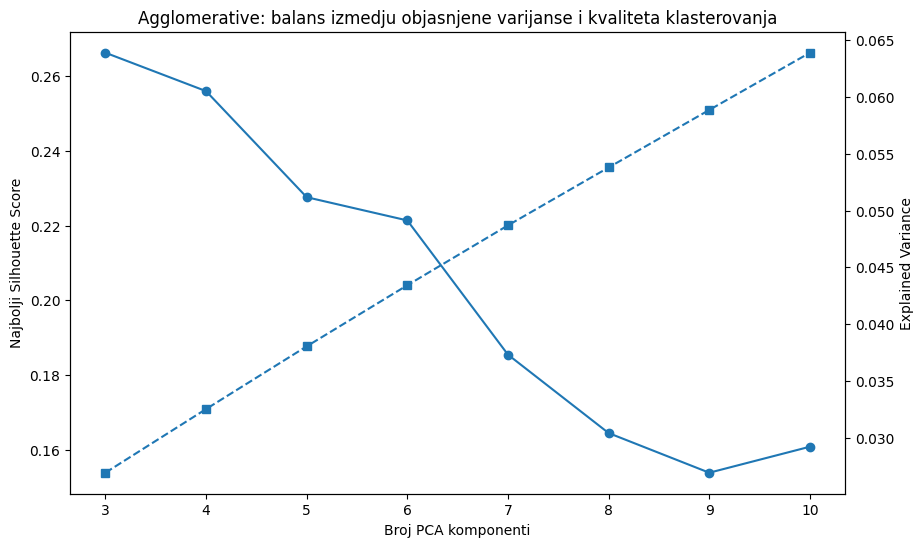

In [20]:
import matplotlib.pyplot as plt

best_agg_by_components = (
    agg_pca_results[
        agg_pca_results["smallest_cluster_pct"] >= 3
    ]
    .sort_values("silhouette", ascending=False)
    .groupby("n_components")
    .head(1)
    .sort_values("n_components")
)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    best_agg_by_components["n_components"],
    best_agg_by_components["silhouette"],
    marker="o"
)

ax1.set_xlabel("Broj PCA komponenti")
ax1.set_ylabel("Najbolji Silhouette Score")

ax2 = ax1.twinx()

ax2.plot(
    best_agg_by_components["n_components"],
    best_agg_by_components["explained_variance"],
    marker="s",
    linestyle="--"
)

ax2.set_ylabel("Explained Variance")

plt.title("Agglomerative: balans izmedju objasnjene varijanse i kvaliteta klasterovanja")
plt.show()

In [12]:
best_agg_row = (
    agg_pca_results[
        agg_pca_results["smallest_cluster_pct"] >= 3
    ]
    .sort_values("silhouette", ascending=False)
    .iloc[0]
)

best_agg_row

n_components                   3
explained_variance      0.026899
linkage                     ward
k                              6
silhouette              0.266285
min_cluster_size             709
max_cluster_size            3595
smallest_cluster_pct        7.09
largest_cluster_pct        35.95
Name: 4, dtype: object

In [13]:
best_n_components = int(best_agg_row["n_components"])
best_linkage = best_agg_row["linkage"]
best_k = int(best_agg_row["k"])

pca_best_agg = PCA(
    n_components=best_n_components,
    random_state=42
)

X_pca_best_agg = pca_best_agg.fit_transform(X_scaled)
X_best_agg_sample = X_pca_best_agg[sample_idx]

best_agg_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_linkage
)

best_agg_labels = best_agg_model.fit_predict(X_best_agg_sample)

pd.Series(best_agg_labels).value_counts(normalize=True) * 100

0    35.95
2    18.76
3    16.73
4    12.63
1     8.84
5     7.09
Name: proportion, dtype: float64

### Vizuelizacija dobijenih klastera

Nakon izbora najbolje konfiguracije, izvrsena je vizuelizacija dobijenih klastera u dvodimenzionalnom i trodimenzionalnom prostoru.

Kako bi prikaz bio pregledniji, podaci su dodatno projektovani na prve dve, odnosno tri glavne komponente pomocu PCA metode. Vazno je naglasiti da se ova transformacija koristi iskljucivo za vizuelizaciju i ne utice na prethodno dobijene rezultate klasterovanja.

Boje predstavljaju pripadnost instanci pojedinim klasterima, dok medjusobni polozaj tacaka omogucava uvid u stepen njihove razdvojenosti i kompaktnosti.

Vizuelnom analizom moguce je proceniti da li dobijeni klasteri formiraju jasno izdvojene grupe ili postoji znacajno preklapanje izmedju njih, sto predstavlja dodatnu proveru kvaliteta klasterovanja pored samih numerickih metrika.

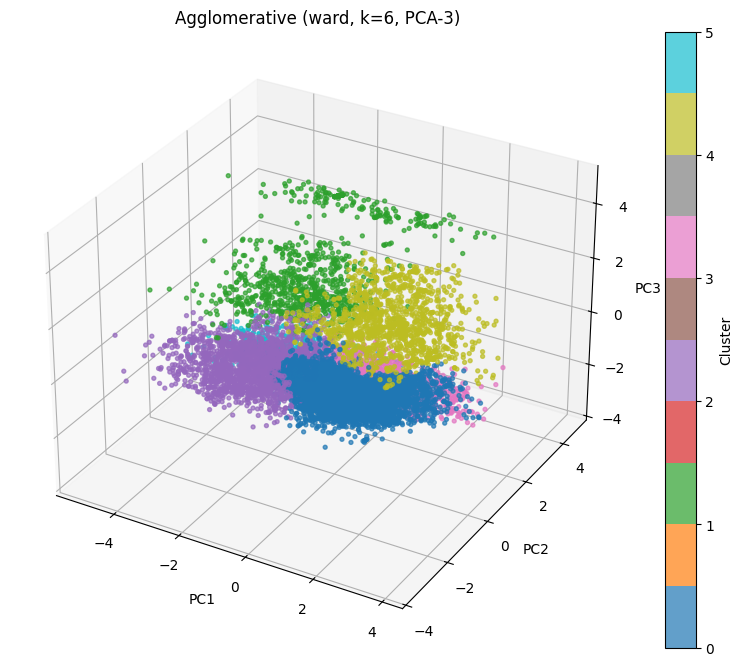

In [14]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

X_vis_3d = PCA(
    n_components=3,
    random_state=42
).fit_transform(X_best_agg_sample)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_vis_3d[:, 0],
    X_vis_3d[:, 1],
    X_vis_3d[:, 2],
    c=best_agg_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

ax.set_title(f"Agglomerative ({best_linkage}, k={best_k}, PCA-{best_n_components})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(scatter, label="Cluster")
plt.show()

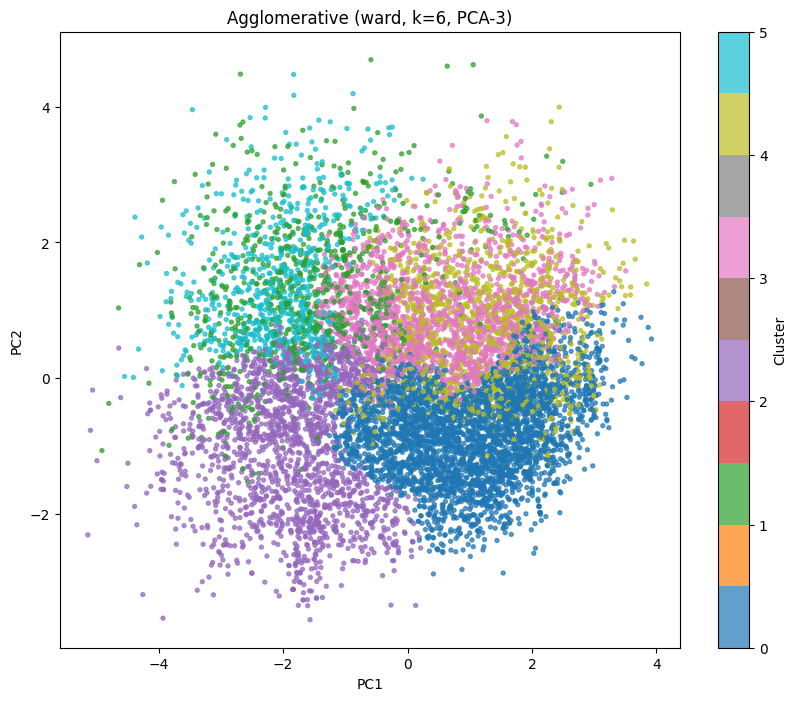

In [15]:
X_vis = PCA(
    n_components=2,
    random_state=42
).fit_transform(X_best_agg_sample)

plt.figure(figsize=(10, 8))

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=best_agg_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title(f"Agglomerative ({best_linkage}, k={best_k}, PCA-{best_n_components})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")

plt.show()

Na osnovu vizuelizacije moze se primetiti da klasteri nisu potpuno jasno razdvojeni, vec postoji odredjeni stepen preklapanja izmedju grupa. Ovakav rezultat je u skladu sa ostvarenim Silhouette Score od 0.266, koji ukazuje na postojanje strukture u podacima, ali ne i na potpuno odvojene klastere.

Ipak, za razliku od konfiguracija sa visim Silhouette Score vrednostima, izabrani model formira znatno uravnotezenije klastere, sto omogucava smisleniju interpretaciju i dalju analizu dobijenih grupa.

In [ ]:
pd.Series(best_agg_labels).to_csv(
    "../../models/agg_labels.csv",
    index=False
)

In [ ]:
np.save("../../models/sample_idx.npy", sample_idx)